# hBN TBSystem-SCC smoke test

This notebook checks the TBSystem-level SCC workflow. `TBSystem` acts as the postprocess scheduler: it owns the structure and model, delegates SCC iterations to `SKSCC`, then reuses the converged SCC state for band-structure style calculations.

The example uses the orthogonal hBN NNSK checkpoint, so the SCC path should auto-select the orthogonal limit `S = I`. The SK files are only used to provide SCC physical parameters such as Hubbard U, occupation, mass, and cutoff radii.

Expected behavior:

- `TBSystem.enable_scc(...)` configures SCC without exposing the lower-level `SKSCC` workflow to downstream band calculations.
- `TBSystem.run_scc()` caches the converged SCC shift and Fermi level.
- `TBSystem.get_hk(..., use_scc=True)` returns the SCC-corrected Hamiltonian.
- `TBSystem.band.compute()` reuses the SCC state automatically after SCC has been run.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from dptb.nn.build import build_model
from dptb.nn.dftb.sk_param import SKParam
from dptb.nn.dftb.scc_params import SCCParams
from dptb.postprocess.unified.system import TBSystem
from dptb.utils.tools import j_loader

Pybinding is not installed. Please install it via `pip install pybinding`


In [2]:
def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "dptb").is_dir():
            return path
    raise RuntimeError("Could not find DeePTB repo root from the current working directory.")


repo = find_repo_root()
example_dir = repo / "examples" / "dftb_scc" / "hBN_scc"
checkpoint = repo / "examples" / "hBN_dftb" / "nnsk" / "checkpoint" / "nnsk.ep500.pth"
struct = example_dir / "data" / "struct.vasp"
band_json = example_dir / "band.json"
sk_path = example_dir / "slakos"

repo, checkpoint, struct, band_json, sk_path

(PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB'),
 PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB/examples/hBN_dftb/nnsk/checkpoint/nnsk.ep500.pth'),
 PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB/examples/dftb_scc/hBN_scc/data/struct.vasp'),
 PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB/examples/dftb_scc/hBN_scc/band.json'),
 PosixPath('/Users/aisiqg/Desktop/work/github/DeePTB/examples/dftb_scc/hBN_scc/slakos'))

Load the orthogonal hBN NNSK checkpoint and create a `TBSystem`. This checkpoint was trained with `common_options.overlap = False`, so the loaded model should not carry an overlap transform.

In [3]:
model = build_model(str(checkpoint))
model.eval()

tbsys = TBSystem(data=str(struct), calculator=model)

print(type(model).__name__)
print("basis:", model.basis)
print("dtype:", model.dtype)
print("has model.overlap:", hasattr(model, "overlap"))
print("TBSystem calculator overlap:", tbsys.calculator.overlap)

assert not hasattr(model, "overlap")
assert tbsys.calculator.overlap is False

The model option atomic_radius in nnsk is not defined in input model_options, set to v1.


NNSK
basis: {'B': ['2s', '2p'], 'N': ['2s', '2p']}
dtype: torch.float32
has model.overlap: False
TBSystem calculator overlap: False


Prepare SCC parameters from the hBN SK files. The model supplies the Hamiltonian; the SK files only provide SCC physical parameters and cutoff radii.

In [4]:
skp = SKParam(basis=model.basis, skdata=str(sk_path), cal_rcuts=True, dtype=torch.float64)
scc_params = SCCParams.from_skparam(skp)

print("r_max from SK files:", scc_params.r_max)
print("available SCC fields:", sorted(scc_params.skdict))
print("Highest_Occu_U from SK files:")
print(scc_params.skdict["Highest_Occu_U"].detach().cpu().numpy())

r_max from SK files: {'B': 4.37, 'N': 4.18}
available SCC fields: ['Highest_Occu_U', 'HubdU', 'Mass', 'Occu']
Highest_Occu_U from SK files:
[[[10.35257244]]

 [[13.30092525]]]


Enable and run SCC through `TBSystem`. The small `[4, 4, 1]` mesh is intended for quick notebook verification; increase it for production comparisons.

In [5]:
tbsys.enable_scc(
    params=scc_params,
    nel_atom={"B": 3, "N": 5},
    kmeshgrid=[4, 4, 1],
    kgamma_center=True,
    krotational_symmetry=False,
    ktime_inversion_symmetry=True,
    AtomicData_options={"r_max": scc_params.r_max},
    mix_rate=0.25,
    max_iter=50,
    Temp=0.1,
    smearing_method="Fermi-Dirac",
)

scc_state = tbsys.run_scc()

print("TBSystem has SCC:", tbsys.has_scc)
print("SKSCC overlap:", tbsys.scc.overlap)
print("Mulliken overlap:", tbsys.scc.mulliken.overlap)
print("converged:", scc_state["is_converged"])
print("E_fermi:", scc_state["E_fermi"])
print("elec_totE:", scc_state["elec_totE"])
print("Mulliken charge:", scc_state["mulliken_charge"])
print("delta charge:", scc_state["delta_charge"])

assert tbsys.has_scc
assert tbsys.scc.overlap is False
assert tbsys.scc.mulliken.overlap is False
assert scc_state["is_converged"]
assert scc_state["scc_shift"] is not None
assert np.isfinite(scc_state["mulliken_charge"]).all()
assert torch.isfinite(scc_state["elec_totE"]).all()

Overwrite the r_max setting in the model with the r_max setting in the AtomicData_options: {'B': 4.37, 'N': 4.18}


This is very dangerous, please make sure you know what you are doing.


/Users/aisiqg/Desktop/work/github/DeePTB/.venv/lib/python3.10/site-packages/torch/nested/__init__.py:107: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:180.)
  return torch._nested_tensor_from_tensor_list(ts, dtype, None, device, None)
eig_solver is not set, using default 'torch'.


TBSystem has SCC: True
SKSCC overlap: False
Mulliken overlap: False
converged: True
E_fermi: -7.208891794465399
elec_totE: tensor([-131.7935], dtype=torch.float64)
Mulliken charge: [5.57588257 2.42411743]
delta charge: [ 0.57588257 -0.57588257]


Compare the bare and SCC-corrected Hamiltonians at Gamma through the TBSystem interface. For this orthogonal model, no overlap matrix is returned.

In [6]:
k_gamma = np.array([[0.0, 0.0, 0.0]], dtype=float)

hk_bare, sk_bare = tbsys.get_hk(k_points=k_gamma, use_scc=False)
hk_scc, sk_scc = tbsys.get_hk(k_points=k_gamma, use_scc=True)
_, eig_scc, vec_scc = tbsys.get_eigenstates(k_points=k_gamma, use_scc=True)

print("bare H(k) shape:", tuple(hk_bare.shape))
print("SCC H(k) shape:", tuple(hk_scc.shape))
print("SCC eigenvalue shape:", tuple(eig_scc.shape))
print("||H_SCC - H0||:", torch.linalg.norm(hk_scc - hk_bare.to(dtype=hk_scc.dtype)).item())

assert sk_bare is None
assert sk_scc is None
assert hk_scc.shape == hk_bare.shape
assert vec_scc.shape[-2:] == hk_scc.shape[-2:]
assert not torch.allclose(hk_scc, hk_bare.to(dtype=hk_scc.dtype))
assert torch.isfinite(eig_scc).all()

bare H(k) shape: (1, 8, 8)
SCC H(k) shape: (1, 8, 8)
SCC eigenvalue shape: (1, 8)
||H_SCC - H0||: 3.6476294537104117


Compute the band path directly through `TBSystem.band`. Since SCC has been run and remains enabled, `band.compute()` automatically uses the SCC-corrected Hamiltonian.

In [7]:
def resolve_example_path(path_value):
    path = Path(path_value)
    if path.is_absolute():
        return path
    return example_dir / str(path_value).removeprefix("./")


jdata = j_loader(str(band_json))
kpath_kwargs = jdata["task_options"]
ref_band = resolve_example_path(kpath_kwargs["ref_band"])

# SCC band through the stateful TBSystem scheduler.
tbsys.band.set_kpath(
    method="abacus",
    kpath=kpath_kwargs["kpath"],
    klabels=kpath_kwargs["klabels"],
)
band_scc = tbsys.band.compute()

# Bare comparison through a separate TBSystem with the same model and structure.
tbsys_bare = TBSystem(data=str(struct), calculator=model)
tbsys_bare.set_efermi(float(scc_state["E_fermi"]))
tbsys_bare.band.set_kpath(
    method="abacus",
    kpath=kpath_kwargs["kpath"],
    klabels=kpath_kwargs["klabels"],
)
band_bare = tbsys_bare.band.compute()

print("SCC band shape:", band_scc.eigenvalues.shape)
print("bare band shape:", band_bare.eigenvalues.shape)
print("max |SCC - bare|:", np.max(np.abs(band_scc.eigenvalues - band_bare.eigenvalues)))

assert band_scc.eigenvalues.shape == band_bare.eigenvalues.shape
assert np.isfinite(band_scc.eigenvalues).all()
assert np.max(np.abs(band_scc.eigenvalues - band_bare.eigenvalues)) > 0.0

eig_solver is not set, using default 'torch'.


SCC band shape: (151, 8)
bare band shape: (151, 8)
max |SCC - bare|: 1.693158589662981


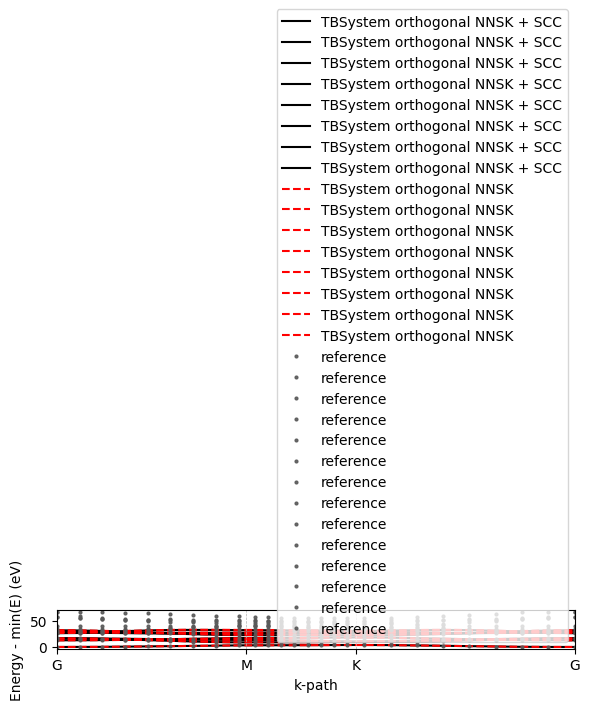

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(
    band_scc.xlist,
    band_scc.eigenvalues - band_scc.eigenvalues.min(),
    "k-",
    label="TBSystem orthogonal NNSK + SCC",
)
plt.plot(
    band_bare.xlist,
    band_bare.eigenvalues - band_bare.eigenvalues.min(),
    "r--",
    label="TBSystem orthogonal NNSK",
)

if ref_band.exists():
    ref = np.squeeze(np.load(ref_band))
    if ref.ndim == 3:
        ref = ref[0]
    ref = ref + band_scc.eigenvalues.min() - ref.min()
    nintp = max(1, len(band_scc.xlist) // 25)
    plt.plot(
        band_scc.xlist[::nintp],
        ref[::nintp] - ref.min(),
        "o",
        ms=2,
        color="0.35",
        alpha=0.9,
        label="reference",
    )

for x in band_scc.high_sym_kpoints[1:-1]:
    plt.axvline(x, color="0.7", lw=0.5, ls="--")
plt.xticks(band_scc.high_sym_kpoints, band_scc.labels)
plt.xlim(band_scc.xlist.min(), band_scc.xlist.max())
plt.ylabel("Energy - min(E) (eV)")
plt.xlabel("k-path")
plt.legend()
plt.tight_layout()